# Courbe d'inflation à 50 ans — Modèle Nelson-Siegel

Ce notebook calibre un modèle de **Nelson-Siegel (NS)** pour construire une courbe d'inflation annuelle sur 50 ans, à partir de 4 inputs utilisateur :

1. **Input 1** : taux d'inflation initial (année 0)
2. **Input 2** : taux d'inflation à long terme (année 50) — la courbe doit y converger
3. **Input 3** : (année, taux cible) — point de calibration intermédiaire n°1
4. **Input 4** : (année, taux cible) — point de calibration intermédiaire n°2

### Modèle

$$y(t) = b_0 + b_1 \cdot \frac{1-e^{-t/\alpha}}{t/\alpha} + b_2 \left(\frac{1-e^{-t/\alpha}}{t/\alpha} - e^{-t/\alpha}\right)$$

- $b_0$ = niveau long terme (input 2)
- $b_1$ = input 1 − input 2 (garantit $y(0)$ = input 1)
- $b_2, \alpha$ = calibrés par optimisation (moindres carrés) sur les points input 3, input 4, et input 2 à l'année 50 (pour forcer la convergence effective à horizon fini).

## 1. Installation / imports

In [82]:
# Sur Colab, scipy et matplotlib sont déjà installés par défaut.
# Cette ligne ne fait rien si c'est déjà le cas, sinon elle installe ce qu'il faut.
!pip install -q scipy matplotlib numpy pandas

In [110]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from google.colab import files

## 2. Fonction Nelson-Siegel

In [84]:
def nelson_siegel(t, b0, b1, b2, alpha):
    """
    Calcule le taux NS pour une ou plusieurs maturités t (en années).
    Gère proprement la limite en t -> 0.
    """
    t = np.asarray(t, dtype=float)
    x = t / alpha

    # f1(t) = (1 - exp(-x)) / x, avec limite f1(0) = 1
    f1 = np.where(x == 0, 1.0, (1 - np.exp(-np.where(x == 0, 1.0, x))) / np.where(x == 0, 1.0, x))
    f2 = f1 - np.exp(-x)

    return b0 + b1 * f1 + b2 * f2

## 3. Calibration de b₂ et α par moindres carrés

In [85]:
def calibrate_ns(b0, b1, target_points, x0=(0.10, 2.0), bounds=([-1.0, 1.0], [1.0, 50.0])):
    """
    target_points : liste de tuples (maturité_en_années, taux_cible)
                    ex : [(3, 0.03), (21, 0.021), (50, 0.02)]
    x0            : valeurs initiales fictives (b2, alpha)

    NB sur les bornes (bounds) : alpha est contraint à >= 1.0. Sans cette
    contrainte, l'optimiseur peut trouver un alpha très petit (< 0.5) qui
    ajuste un peu mieux les 3 points cibles mais produit une courbe avec
    une légère "bosse" non monotone entre t=0 et le premier point cible
    (la composante de courbure b2 devient alors très locale). La borne
    alpha >= 1.0 donne une courbe économiquement plus réaliste (décroissance
    /convergence lisse) pour un coût quasi nul en qualité d'ajustement
    (écarts < 0.1 pt de % sur les points cibles). Élargissez les bornes si
    vous voulez explicitement autoriser plus de courbure à court terme.
    Retourne (b2_opt, alpha_opt, résultat_optimisation)
    """
    t_arr = np.array([p[0] for p in target_points], dtype=float)
    y_arr = np.array([p[1] for p in target_points], dtype=float)

    def residuals(params):
        b2, alpha = params
        model_vals = nelson_siegel(t_arr, b0, b1, b2, alpha)
        return model_vals - y_arr

    result = least_squares(residuals, x0=list(x0), bounds=bounds)
    b2_opt, alpha_opt = result.x
    return b2_opt, alpha_opt, result

## 4. Construction complète de la courbe à partir des 4 inputs

In [86]:
def build_inflation_curve(infl_0, infl_50,
                           annee_a, infl_a,
                           annee_b, infl_b,
                           horizon=50,
                           b2_alpha_init=(0.10, 2.0)):
    """
    infl_0   : input 1 - taux d'inflation initial (t=0), ex. 0.04
    infl_50  : input 2 - taux d'inflation long terme (t=50), ex. 0.02
    annee_a, infl_a : input 3 - (année, taux cible), ex. (3, 0.03)
    annee_b, infl_b : input 4 - (année, taux cible), ex. (21, 0.021)
    horizon  : nombre d'années de la courbe (défaut 50)
    """
    # Paramètres fixés par construction
    b0 = infl_50
    b1 = infl_0 - infl_50

    # Points de calibration pour b2 et alpha :
    # les deux points définis par l'utilisateur + le niveau long terme
    # (pour forcer la convergence effective à l'horizon 50 ans)
    target_points = [(annee_a, infl_a), (annee_b, infl_b), (horizon, infl_50)]

    b2, alpha, opt_res = calibrate_ns(b0, b1, target_points, x0=b2_alpha_init)

    # Courbe annuelle sur l'horizon demandé
    years = np.arange(0, horizon + 1)
    curve = nelson_siegel(years, b0, b1, b2, alpha)

    params = {"b0": b0, "b1": b1, "b2": b2, "alpha": alpha}
    return years, curve, params, opt_res, target_points

## 5. Inputs utilisateur

👉 Modifiez les 4 valeurs ci-dessous selon votre scénario.

In [87]:
# ---- INPUTS UTILISATEUR (à modifier) ----
infl_0 = 0.04                 # input 1 : inflation initiale (t=0)
infl_50 = 0.02                # input 2 : inflation long terme (t=50)
annee_a, infl_a = 3, 0.0194     # input 3 : (année, taux cible)
annee_b, infl_b = 21, 0.022   # input 4 : (année, taux cible)
# ------------------------------------------

## 6. Generation Yearly Inflation et vérification

In [88]:
years, curve, params, opt_res, target_points = build_inflation_curve(
    infl_0, infl_50, annee_a, infl_a, annee_b, infl_b
)

print("Paramètres calibrés du modèle Nelson-Siegel :")
for k, v in params.items():
    print(f"  {k:6s} = {v:.6f}")
print(f"\nConvergence optimisation : {opt_res.success} ({opt_res.message})")

print("\nVérification aux points cibles :")
for t, target in target_points:
    modeled = nelson_siegel(t, **params)
    print(f"  Année {t:>3.0f} : cible = {target:6.3%}  |  modèle = {modeled:6.3%}  "
          f"|  écart = {(modeled - target)*100:+.3f} pts")

Paramètres calibrés du modèle Nelson-Siegel :
  b0     = 0.020000
  b1     = 0.020000
  b2     = -0.024474
  alpha  = 1.000000

Convergence optimisation : True (`gtol` termination condition is satisfied.)

Vérification aux points cibles :
  Année   3 : cible = 1.940%  |  modèle = 1.980%  |  écart = +0.040 pts
  Année  21 : cible = 2.200%  |  modèle = 1.979%  |  écart = -0.221 pts
  Année  50 : cible = 2.000%  |  modèle = 1.991%  |  écart = -0.009 pts


In [89]:
df = pd.DataFrame({"Année": years, "Inflation": curve})
df["Inflation (%)"] = (df["Inflation"] * 100).round(3)
df[["Année", "Inflation (%)"]]

,Année,Inflation (%)
0,0,4.000
1,1,2.618
2,2,2.138
3,3,1.980
4,4,1.935
5,5,1.928
6,6,1.932
7,7,1.938
8,8,1.945
9,9,1.951


In [90]:
# Extraction des années et des taux d'inflation annuels
annual_years = df['Année'].values
annual_inflation = df['Inflation'].values

## Intrapolation Monthly

Nous allons créer une fonction d'interpolation à partir de nos données annuelles. L'option `kind='cubic'` spécifie que nous utilisons une interpolation cubique. `fill_value='extrapolate'` permet d'estimer des valeurs en dehors de la plage de données si nécessaire, bien que pour notre cas (de 0 à 50 ans), ce ne soit pas strictement nécessaire si nous restons dans cette plage.

In [91]:
# Création de la fonction d'interpolation (cubique pour la douceur)
f_interp = interp1d(annual_years, annual_inflation, kind='cubic', fill_value='extrapolate')

Maintenant, nous allons générer une nouvelle série de points pour les mois. Pour 50 ans, cela représente 50 * 12 = 600 mois. Nous utiliserons des valeurs fractionnaires pour les années (ex: 0.0, 1/12, 2/12, ..., 50.0).

In [92]:
# Génération des points mensuels (en fractions d'années), de t=1/12 (Jan An 1) à t=50 (Dec An 50)
monthly_time_points_for_months = np.arange(1/12, 50 + 1/12, 1/12) # Cela génère 600 points

# Calcul de l'inflation mensuelle interpolée pour ces 600 points
inflation_for_months = f_interp(monthly_time_points_for_months)

# Calcul des colonnes Année et Mois pour ces 600 points
# L'année est le plafond du temps fractionnaire (ex: 0.08 -> An 1, 1.0 -> An 1, 1.08 -> An 2)
annee_col = np.ceil(monthly_time_points_for_months).astype(int)
# Le mois est calculé en fonction de la fraction de l'année en cours
mois_col = np.round((monthly_time_points_for_months - (np.ceil(monthly_time_points_for_months)-1)) * 12).astype(int)

# Création du DataFrame pour les 600 mois
df_monthly_temp = pd.DataFrame({
    'Temps_Fraction_Annee': monthly_time_points_for_months,
    'Annee': annee_col,
    'Mois': mois_col,
    'Inflation': inflation_for_months
})

# Formatage de la colonne Mois_Annee comme 'MM/YY'
df_monthly_temp['Mois_Annee'] = df_monthly_temp.apply(lambda row: f"{int(row['Mois']):02d}/{int(row['Annee']):02d}", axis=1)

# Ajout de la ligne d'inflation initiale (t=0) au début
initial_row = pd.DataFrame({
    'Temps_Fraction_Annee': [0.0],
    'Annee': [np.nan],
    'Mois': [np.nan],
    'Inflation': [infl_0],
    'Mois_Annee': ['Initial']
})

df_monthly = pd.concat([initial_row, df_monthly_temp], ignore_index=True)

df_monthly['Inflation (%)'] = (df_monthly['Inflation'] * 100).round(4)

# Affichage des premières et dernières lignes pour vérification
print("Premières 15 lignes du DataFrame mensuel (601 points incluant 'Initial') :")
display(df_monthly.head(15))
print("\nDernières 5 lignes du DataFrame mensuel :")
display(df_monthly.tail(5))
print(f"\nNombre total de points générés : {len(df_monthly)}")

# --- Vérification des valeurs de Décembre ---
print("\n--- Vérification : Inflation de Décembre (mensuel) vs Inflation Annuelle (df) ---")
verification_results = []
for year in range(1, 51): # Pour les années 1 à 50
    # Inflation mensuelle de Décembre de l'année courante
    dec_inflation_monthly = df_monthly[(df_monthly['Annee'] == year) & (df_monthly['Mois'] == 12)]['Inflation'].iloc[0]

    # Inflation annuelle de l'année courante (du DataFrame original 'df')
    annual_inflation_df = df[df['Année'] == year]['Inflation'].iloc[0]

    # Écart en points de pourcentage
    ecart = (dec_inflation_monthly - annual_inflation_df) * 100
    verification_results.append({
        'Année': year,
        'Dec_Mensuel (%)': dec_inflation_monthly * 100,
        'Annuel_DF (%)': annual_inflation_df * 100,
        'Écart_pts': ecart
    })

df_verification = pd.DataFrame(verification_results)
display(df_verification.head())
display(df_verification.tail())
print(f"\nNombre d'écarts (valeur absolue) > 0.001 pts : {(df_verification['Écart_pts'].abs() > 0.001).sum()} sur 50 années")
print("Si ce nombre est faible, l'interpolation fonctionne bien aux points annuels de Décembre.")

Premières 15 lignes du DataFrame mensuel (601 points incluant 'Initial') :


,Temps_Fraction_Annee,Annee,Mois,Inflation,Mois_Annee,Inflation (%)
0,0.000000,NaN,NaN,0.040000,Initial,4.0000
1,0.083333,1.0,1.0,0.038339,01/01,3.8339
2,0.166667,1.0,2.0,0.036784,02/01,3.6784
3,0.250000,1.0,3.0,0.035330,03/01,3.5330
4,0.333333,1.0,4.0,0.033974,04/01,3.3974
5,0.416667,1.0,5.0,0.032712,05/01,3.2712
6,0.500000,1.0,6.0,0.031540,06/01,3.1540
7,0.583333,1.0,7.0,0.030453,07/01,3.0453
8,0.666667,1.0,8.0,0.029449,08/01,2.9449
9,0.750000,1.0,9.0,0.028523,09/01,2.8523



Dernières 5 lignes du DataFrame mensuel :


,Temps_Fraction_Annee,Annee,Mois,Inflation,Mois_Annee,Inflation (%)
596,49.666667,50.0,8.0,0.019910,08/50,1.9910
597,49.750000,50.0,9.0,0.019910,09/50,1.9910
598,49.833333,50.0,10.0,0.019910,10/50,1.9910
599,49.916667,50.0,11.0,0.019910,11/50,1.9910
600,50.000000,50.0,12.0,0.019911,12/50,1.9911



Nombre total de points générés : 601

--- Vérification : Inflation de Décembre (mensuel) vs Inflation Annuelle (df) ---


,Année,Dec_Mensuel (%),Annuel_DF (%),Écart_pts
0,1,2.617544,2.617544,0.000000e+00
1,2,2.137801,2.137801,3.469447e-16
2,3,1.980147,1.980147,0.000000e+00
3,4,1.935030,1.935030,0.000000e+00
4,5,1.927618,1.927618,0.000000e+00


,Année,Dec_Mensuel (%),Annuel_DF (%),Écart_pts
45,46,1.990274,1.990274,0.000000e+00
46,47,1.990481,1.990481,0.000000e+00
47,48,1.990680,1.990680,0.000000e+00
48,49,1.990870,1.990870,3.469447e-16
49,50,1.991052,1.991052,0.000000e+00



Nombre d'écarts (valeur absolue) > 0.001 pts : 0 sur 50 années
Si ce nombre est faible, l'interpolation fonctionne bien aux points annuels de Décembre.


Vous pouvez maintenant visualiser cette courbe mensuelle pour voir son aspect plus détaillé.

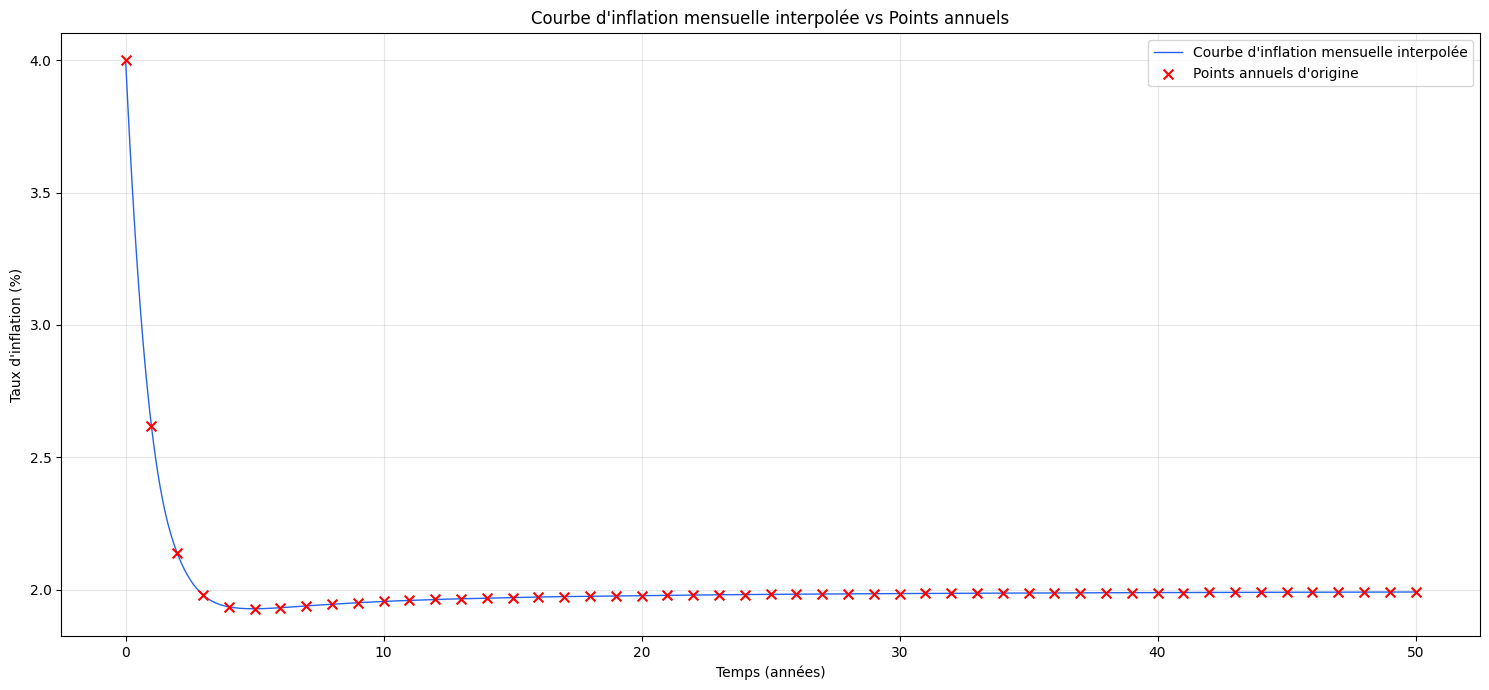

In [93]:
plt.figure(figsize=(15, 7))
plt.plot(df_monthly['Temps_Fraction_Annee'], df_monthly['Inflation (%)'], label="Courbe d'inflation mensuelle interpolée", color='#2563eb', linewidth=1)
plt.scatter(annual_years, annual_inflation * 100, label="Points annuels d'origine", color='red', marker='x', s=50, zorder=5)

plt.title("Courbe d'inflation mensuelle interpolée vs Points annuels")
plt.xlabel("Temps (années)")
plt.ylabel("Taux d'inflation (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Graphique df Inflation Annuel

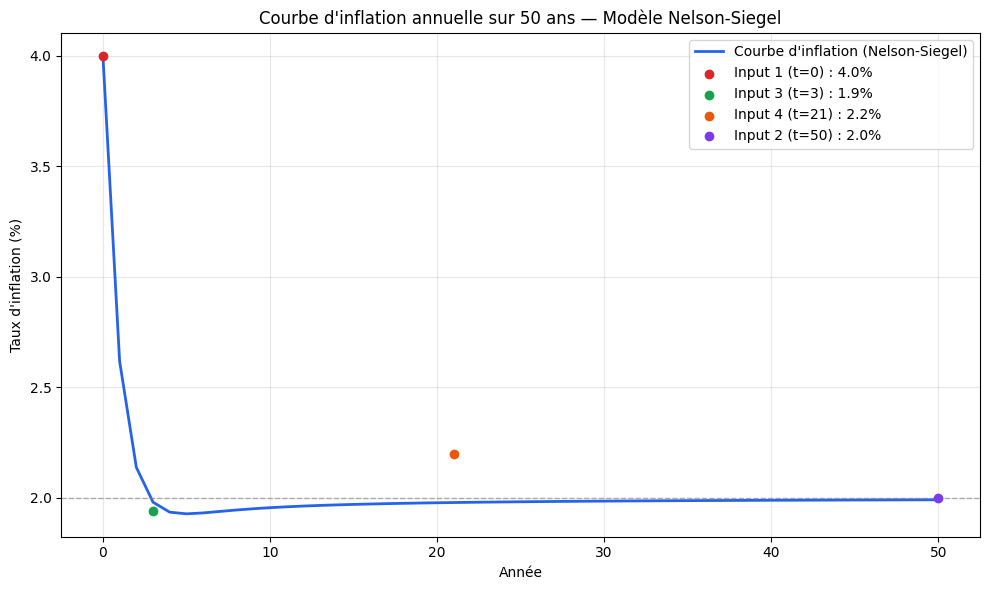

In [94]:
plt.figure(figsize=(10, 6))
plt.plot(years, curve * 100, label="Courbe d'inflation (Nelson-Siegel)", color="#2563eb", linewidth=2)
plt.scatter([0], [infl_0 * 100], color="#dc2626", zorder=5, label=f"Input 1 (t=0) : {infl_0:.1%}")
plt.scatter([annee_a], [infl_a * 100], color="#16a34a", zorder=5, label=f"Input 3 (t={annee_a}) : {infl_a:.1%}")
plt.scatter([annee_b], [infl_b * 100], color="#ea580c", zorder=5, label=f"Input 4 (t={annee_b}) : {infl_b:.1%}")
plt.scatter([50], [infl_50 * 100], color="#7c3aed", zorder=5, label=f"Input 2 (t=50) : {infl_50:.1%}")
plt.axhline(infl_50 * 100, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.title("Courbe d'inflation annuelle sur 50 ans — Modèle Nelson-Siegel")
plt.xlabel("Année")
plt.ylabel("Taux d'inflation (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8.Export de la courbe en CSV

Pratique pour réutiliser les résultats ailleurs (Excel, autre modèle, etc.).

In [111]:
def export_dfs_to_excel(dfs_to_export, excel_file_name="output.xlsx"):
    """
    Exporte plusieurs DataFrames dans un seul fichier Excel, chaque DataFrame étant une feuille distincte.
    Permet ensuite le téléchargement du fichier.

    Args:
        dfs_to_export (dict): Un dictionnaire où les clés sont les noms des feuilles (str)
                              et les valeurs sont les DataFrames (pd.DataFrame) à exporter.
        excel_file_name (str): Le nom du fichier Excel à créer.
    """
    if not isinstance(dfs_to_export, dict) or not all(isinstance(v, pd.DataFrame) for v in dfs_to_export.values()):
        print("Erreur: 'dfs_to_export' doit être un dictionnaire de DataFrames.")
        return

    try:
        with pd.ExcelWriter(excel_file_name, engine="openpyxl") as writer:
            for sheet_name, df_to_write in dfs_to_export.items():
                df_to_write.to_excel(writer, sheet_name=sheet_name, index=False)

        print(f"Fichier créé : {excel_file_name}")

        # Téléchargement
        files.download(excel_file_name)
    except Exception as e:
        print(f"Une erreur est survenue lors de l'exportation ou du téléchargement : {e}")


# Simple NS sans cibles

In [98]:
def build_inflation_curve_no_targets(infl_0, infl_50, b2_param, alpha_param, horizon=50):
    """
    Construit une courbe d'inflation Nelson-Siegel sans calibration sur des points cibles.
    b2 et alpha sont fournis directement en paramètres.

    infl_0      : taux d'inflation initial (t=0)
    infl_50     : taux d'inflation long terme (t=50)
    b2_param    : paramètre b2 du modèle Nelson-Siegel (courbure)
    alpha_param : paramètre alpha du modèle Nelson-Siegel (taux de décroissance de la courbure)
    horizon     : nombre d'années de la courbe (défaut 50)
    """
    # Paramètres fixés par construction
    b0 = infl_50
    b1 = infl_0 - infl_50

    # Courbe annuelle sur l'horizon demandé
    years = np.arange(0, horizon + 1)
    curve = nelson_siegel(years, b0, b1, b2_param, alpha_param)

    params = {"b0": b0, "b1": b1, "b2": b2_param, "alpha": alpha_param}
    return years, curve, params


--- Modèle Nelson-Siegel sans points cibles ---
Paramètres du modèle Nelson-Siegel (sans cibles) :
  b0     = 0.020000
  b1     = 0.020000
  b2     = 0.000000
  alpha  = 2.000000


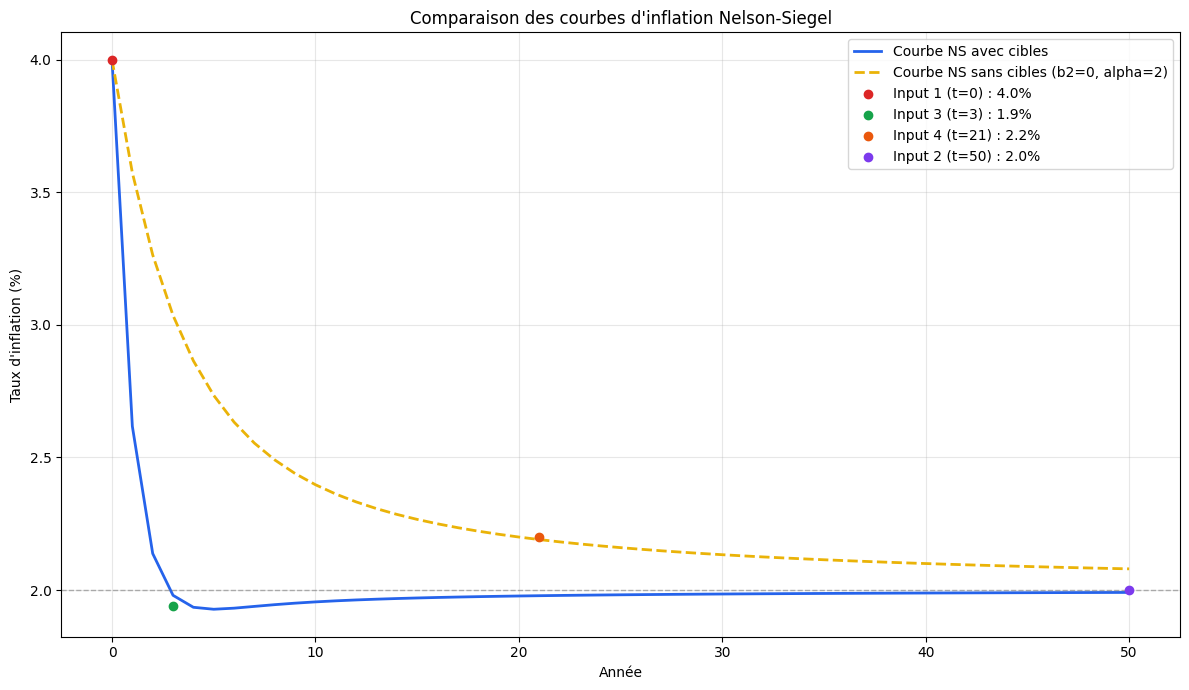

In [99]:
# --- Utilisation du modèle sans cibles ---
print("\n--- Modèle Nelson-Siegel sans points cibles ---")

# Définir directement b2 et alpha
b2_no_targets = 0.0  # Par exemple, supprimer le terme de courbure
alpha_no_targets = 2.0 # Une valeur typique pour alpha


years_no_targets, curve_no_targets, params_no_targets = build_inflation_curve_no_targets(
    infl_0, infl_50, b2_no_targets, alpha_no_targets
)

print("Paramètres du modèle Nelson-Siegel (sans cibles) :")
for k, v in params_no_targets.items():
    print(f"  {k:6s} = {v:.6f}")

# --- Comparaison des deux courbes ---

# Renommer les variables de la courbe avec cibles pour plus de clarté dans le graphique
years_with_targets = years
curve_with_targets = curve

plt.figure(figsize=(12, 7))
plt.plot(years_with_targets, curve_with_targets * 100, label="Courbe NS avec cibles", color="#2563eb", linewidth=2)
plt.plot(years_no_targets, curve_no_targets * 100, label="Courbe NS sans cibles (b2=0, alpha=2)", color="#eab308", linestyle="--", linewidth=2)

plt.scatter([0], [infl_0 * 100], color="#dc2626", zorder=5, label=f"Input 1 (t=0) : {infl_0:.1%}")
plt.scatter([annee_a], [infl_a * 100], color="#16a34a", zorder=5, label=f"Input 3 (t={annee_a}) : {infl_a:.1%}")
plt.scatter([annee_b], [infl_b * 100], color="#ea580c", zorder=5, label=f"Input 4 (t={annee_b}) : {infl_b:.1%}")
plt.scatter([50], [infl_50 * 100], color="#7c3aed", zorder=5, label=f"Input 2 (t=50) : {infl_50:.1%}")
plt.axhline(infl_50 * 100, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.title("Comparaison des courbes d'inflation Nelson-Siegel")
plt.xlabel("Année")
plt.ylabel("Taux d'inflation (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [100]:
df_no_targets = pd.DataFrame({"Année": years_no_targets, "Inflation": curve_no_targets})
df_no_targets["Inflation (%)"] = (df["Inflation"] * 100).round(3)
df_no_targets[["Année", "Inflation (%)"]]

,Année,Inflation (%)
0,0,4.000
1,1,2.618
2,2,2.138
3,3,1.980
4,4,1.935
5,5,1.928
6,6,1.932
7,7,1.938
8,8,1.945
9,9,1.951


In [101]:
# Extraction des années et des taux d'inflation annuels
annual_years_no_targets = df_no_targets['Année'].values
annual_inflation_no_targets = df_no_targets['Inflation'].values

# Intrapolation No Targets

In [104]:
# Création de la fonction d'interpolation (cubique pour la douceur)
f_interp_no_targets = interp1d(annual_years_no_targets, annual_inflation_no_targets, kind='cubic', fill_value='extrapolate')

# Génération des points mensuels (en fractions d'années), de t=1/12 (Jan An 1) à t=50 (Dec An 50)
monthly_time_points_for_months = np.arange(1/12, 50 + 1/12, 1/12) # Cela génère 600 points

# Calcul de l'inflation mensuelle interpolée pour ces 600 points
inflation_for_months = f_interp_no_targets(monthly_time_points_for_months)

# Calcul des colonnes Année et Mois pour ces 600 points
# L'année est le plafond du temps fractionnaire (ex: 0.08 -> An 1, 1.0 -> An 1, 1.08 -> An 2)
annee_col = np.ceil(monthly_time_points_for_months).astype(int)
# Le mois est calculé en fonction de la fraction de l'année en cours
mois_col = np.round((monthly_time_points_for_months - (np.ceil(monthly_time_points_for_months)-1)) * 12).astype(int)

# Création du DataFrame pour les 600 mois
df_monthly_temp = pd.DataFrame({
    'Temps_Fraction_Annee': monthly_time_points_for_months,
    'Annee': annee_col,
    'Mois': mois_col,
    'Inflation': inflation_for_months
})

# Formatage de la colonne Mois_Annee comme 'MM/YY'
df_monthly_temp['Mois_Annee'] = df_monthly_temp.apply(lambda row: f"{int(row['Mois']):02d}/{int(row['Annee']):02d}", axis=1)

# Ajout de la ligne d'inflation initiale (t=0) au début
initial_row = pd.DataFrame({
    'Temps_Fraction_Annee': [0.0],
    'Annee': [np.nan],
    'Mois': [np.nan],
    'Inflation': [infl_0],
    'Mois_Annee': ['Initial']
})

df_monthly_no_targets = pd.concat([initial_row, df_monthly_temp], ignore_index=True)

df_monthly_no_targets['Inflation (%)'] = (df_monthly['Inflation'] * 100).round(4)

# Affichage des premières et dernières lignes pour vérification
print("Premières 15 lignes du DataFrame mensuel (601 points incluant 'Initial') :")
display(df_monthly_no_targets.head(15))
print("\nDernières 5 lignes du DataFrame mensuel :")
display(df_monthly_no_targets.tail(5))
print(f"\nNombre total de points générés : {len(df_monthly_no_targets)}")

# --- Vérification des valeurs de Décembre ---
print("\n--- Vérification : Inflation de Décembre (mensuel) vs Inflation Annuelle (df) ---")
verification_results_no_targets = []
for year in range(1, 51): # Pour les années 1 à 50
    # Inflation mensuelle de Décembre de l'année courante
    dec_inflation_monthly_no_targets = df_monthly_no_targets[(df_monthly_no_targets['Annee'] == year) & (df_monthly_no_targets['Mois'] == 12)]['Inflation'].iloc[0]

    # Inflation annuelle de l'année courante (du DataFrame original 'df')
    annual_inflation_df_no_targets = df_no_targets[df_no_targets['Année'] == year]['Inflation'].iloc[0]

    # Écart en points de pourcentage
    ecart = (dec_inflation_monthly_no_targets - annual_inflation_df_no_targets) * 100
    verification_results_no_targets.append({
        'Année': year,
        'Dec_Mensuel (%)': dec_inflation_monthly_no_targets * 100,
        'Annuel_DF (%)': annual_inflation_df_no_targets * 100,
        'Écart_pts': ecart
    })

df_verification_no_targets = pd.DataFrame(verification_results)
display(df_verification_no_targets.head())
display(df_verification_no_targets.tail())
print(f"\nNombre d'écarts (valeur absolue) > 0.001 pts : {(df_verification['Écart_pts'].abs() > 0.001).sum()} sur 50 années")
print("Si ce nombre est faible, l'interpolation fonctionne bien aux points annuels de Décembre.")

Premières 15 lignes du DataFrame mensuel (601 points incluant 'Initial') :


,Temps_Fraction_Annee,Annee,Mois,Inflation,Mois_Annee,Inflation (%)
0,0.000000,NaN,NaN,0.040000,Initial,4.0000
1,0.083333,1.0,1.0,0.039591,01/01,3.9591
2,0.166667,1.0,2.0,0.039193,02/01,3.9193
3,0.250000,1.0,3.0,0.038805,03/01,3.8805
4,0.333333,1.0,4.0,0.038427,04/01,3.8427
5,0.416667,1.0,5.0,0.038059,05/01,3.8059
6,0.500000,1.0,6.0,0.037700,06/01,3.7700
7,0.583333,1.0,7.0,0.037351,07/01,3.7351
8,0.666667,1.0,8.0,0.037011,08/01,3.7011
9,0.750000,1.0,9.0,0.036680,09/01,3.6680



Dernières 5 lignes du DataFrame mensuel :


,Temps_Fraction_Annee,Annee,Mois,Inflation,Mois_Annee,Inflation (%)
596,49.666667,50.0,8.0,0.020805,08/50,2.0805
597,49.750000,50.0,9.0,0.020804,09/50,2.0804
598,49.833333,50.0,10.0,0.020803,10/50,2.0803
599,49.916667,50.0,11.0,0.020801,11/50,2.0801
600,50.000000,50.0,12.0,0.020800,12/50,2.0800



Nombre total de points générés : 601

--- Vérification : Inflation de Décembre (mensuel) vs Inflation Annuelle (df) ---


,Année,Dec_Mensuel (%),Annuel_DF (%),Écart_pts
0,1,3.573877,2.617544,0.956334
1,2,3.264241,2.137801,1.126440
2,3,3.035826,1.980147,1.055680
3,4,2.864665,1.935030,0.929635
4,5,2.734332,1.927618,0.806714


,Année,Dec_Mensuel (%),Annuel_DF (%),Écart_pts
45,46,2.086957,1.990274,0.096682
46,47,2.085106,1.990481,0.094625
47,48,2.083333,1.990680,0.092654
48,49,2.081633,1.990870,0.090763
49,50,2.080000,1.991052,0.088948



Nombre d'écarts (valeur absolue) > 0.001 pts : 50 sur 50 années
Si ce nombre est faible, l'interpolation fonctionne bien aux points annuels de Décembre.


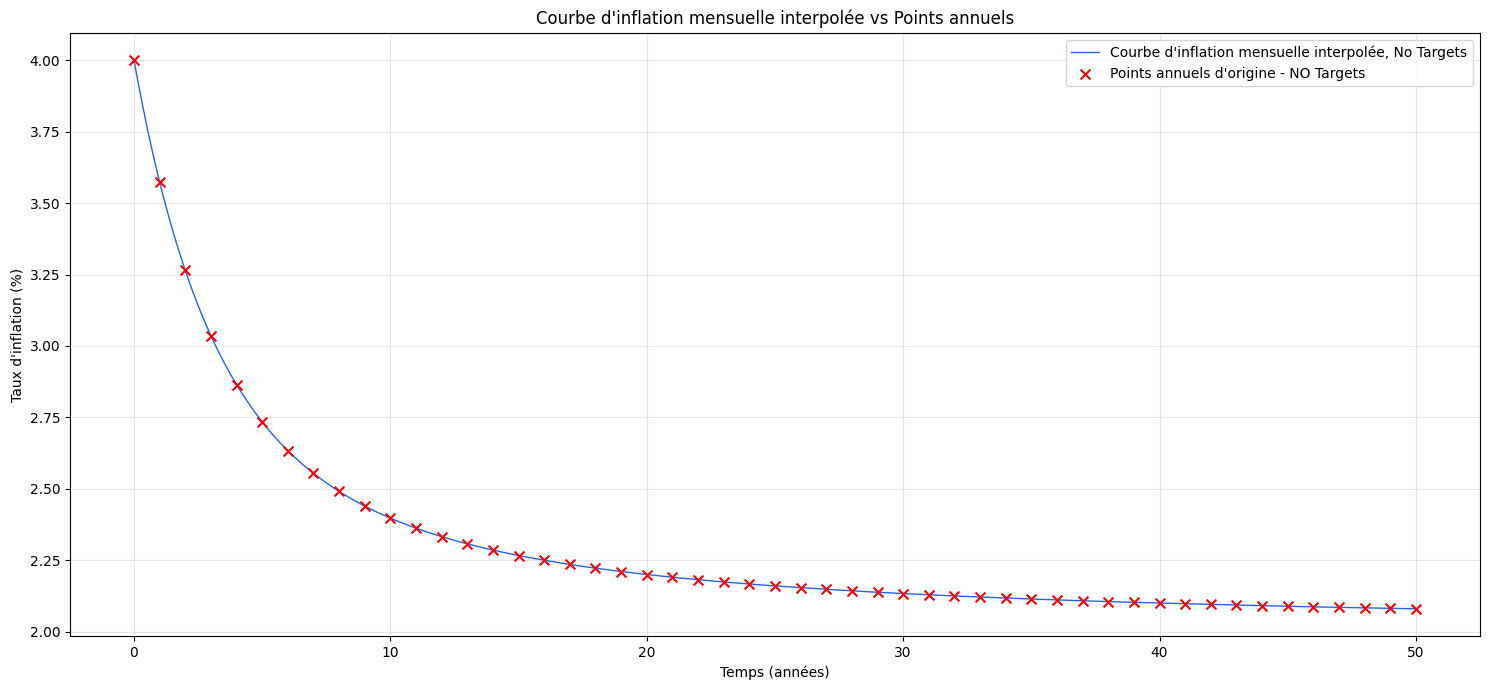

In [105]:
plt.figure(figsize=(15, 7))
plt.plot(df_monthly_no_targets['Temps_Fraction_Annee'], df_monthly_no_targets['Inflation (%)'], label="Courbe d'inflation mensuelle interpolée, No Targets", color='#2563eb', linewidth=1)
plt.scatter(annual_years, annual_inflation_no_targets * 100, label="Points annuels d'origine - NO Targets", color='red', marker='x', s=50, zorder=5)

plt.title("Courbe d'inflation mensuelle interpolée vs Points annuels")
plt.xlabel("Temps (années)")
plt.ylabel("Taux d'inflation (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [106]:
df_no_targets[["Année", "Inflation (%)"]].to_csv("courbe_inflation_nelson_siegel_NO_Targets.csv", index=False)
print("Fichier exporté : courbe_inflation_nelson_siegel_NO_Targets.csv")

Fichier exporté : courbe_inflation_nelson_siegel_NO_Targets.csv


# Expor Output

In [112]:
# Définir les DataFrames à exporter dans un dictionnaire
excel_dfs = {
   "Annuel_Avec_Cibles": df,
   "Mensuel_Avec_Cibles": df_monthly,
   "Annuel_Sans_Cibles": df_no_targets,
   "Mensuel_Sans_Cibles": df_monthly_no_targets
}

# Nom du fichier Excel
output_file = "Courbes_Inflation_Completes.xlsx"

# Appel de la fonction pour exporter et télécharger
export_dfs_to_excel(excel_dfs, output_file)

Fichier créé : Courbes_Inflation_Completes.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>